In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

pd.set_option('display.float_format', '{:.3f}'.format)

# ========================
# 1. PARÁMETROS DEL DISEÑO
# ========================

f_res = 11e6
f_res_mhz = f_res/1e6   
BW = 0.1 * f_res

Do_cm = 2.38  # Diámetro del núcleo (palo de escoba) (cm)
Diametros_cm = np.array([0.18, 0.20]) # Diámetros de cobre disponibles (cm)
Se_cm = Diametros_cm # Separación entre espiras

print("Diámetros de cobre (cm):", Diametros_cm)
print()

Diámetros de cobre (cm): [0.18 0.2 ]



In [20]:
# =================
# 2. DIÁMETRO TOTAL
# =================

Dtotal_cm = Do_cm + 2*Diametros_cm

print("Diámetro total bobina (cm):",Dtotal_cm)
print()


Diámetro total bobina (cm): [2.74 2.78]



In [21]:
# ===============
# 3. RELACIÓN L/D
# ===============

RelacionLD = np.arange(1, 2.05, 0.05)

filas = [f"L/D={r:.2f}" for r in RelacionLD]
columnas = [f"d_cu={d:.2f}cm" for d in Diametros_cm]

In [22]:
# ===============
# 4. LARGO BOBINA
# ===============

Largo_cm = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        Largo_cm[i,j] = RelacionLD[i]*Dtotal_cm[j]

df_largos = pd.DataFrame(Largo_cm, index=filas, columns=columnas)

print("LARGO DE BOBINA (cm)")
print(df_largos)
print()


LARGO DE BOBINA (cm)
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00        2.740        2.780
L/D=1.05        2.877        2.919
L/D=1.10        3.014        3.058
L/D=1.15        3.151        3.197
L/D=1.20        3.288        3.336
L/D=1.25        3.425        3.475
L/D=1.30        3.562        3.614
L/D=1.35        3.699        3.753
L/D=1.40        3.836        3.892
L/D=1.45        3.973        4.031
L/D=1.50        4.110        4.170
L/D=1.55        4.247        4.309
L/D=1.60        4.384        4.448
L/D=1.65        4.521        4.587
L/D=1.70        4.658        4.726
L/D=1.75        4.795        4.865
L/D=1.80        4.932        5.004
L/D=1.85        5.069        5.143
L/D=1.90        5.206        5.282
L/D=1.95        5.343        5.421
L/D=2.00        5.480        5.560



In [23]:

# ====================
# 5. NÚMERO DE ESPIRAS
# ====================

pitch = Diametros_cm + Se_cm

N = np.zeros((len(RelacionLD),len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        N[i,j] = Largo_cm[i,j]/pitch[j]

df_espiras = pd.DataFrame(N, index=filas, columns=columnas)

print("NÚMERO DE ESPIRAS")
print(df_espiras)
print()


NÚMERO DE ESPIRAS
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00        7.611        6.950
L/D=1.05        7.992        7.297
L/D=1.10        8.372        7.645
L/D=1.15        8.753        7.992
L/D=1.20        9.133        8.340
L/D=1.25        9.514        8.688
L/D=1.30        9.894        9.035
L/D=1.35       10.275        9.383
L/D=1.40       10.656        9.730
L/D=1.45       11.036       10.078
L/D=1.50       11.417       10.425
L/D=1.55       11.797       10.773
L/D=1.60       12.178       11.120
L/D=1.65       12.558       11.468
L/D=1.70       12.939       11.815
L/D=1.75       13.319       12.163
L/D=1.80       13.700       12.510
L/D=1.85       14.081       12.858
L/D=1.90       14.461       13.205
L/D=1.95       14.842       13.553
L/D=2.00       15.222       13.900



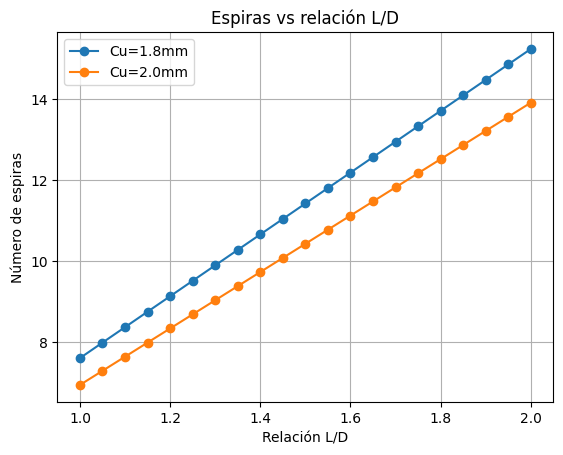

In [24]:
# ===================================
# 6. GRÁFICO L/D vs Número de espiras
# ===================================

plt.figure()

for j in range(len(Diametros_cm)):
    plt.plot(RelacionLD,N[:,j], marker='o', label=f"Cu={Diametros_cm[j]*10:.1f}mm")

plt.xlabel("Relación L/D")
plt.ylabel("Número de espiras")
plt.title("Espiras vs relación L/D")
plt.grid()
plt.legend()

plt.show()

In [25]:
# ==============
# 7. INDUCTANCIA
# ==============

# Fórmula de Wheeler para bobinas de una capa

r_cm = Dtotal_cm / 2 # Radio de bobina

inductancia_uh = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        inductancia_uh[i,j] = (0.394 * (r_cm[j]**2) * (N[i,j]**2)) / (9*r_cm[j] + 10*Largo_cm[i,j])

df_inductancias = pd.DataFrame(inductancia_uh, index=filas, columns=columnas)

print("TABLA DE INDUCTANCIAS DE BOBINA (uH)")
print(df_inductancias)
print()

TABLA DE INDUCTANCIAS DE BOBINA (uH)
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00        1.078        0.912
L/D=1.05        1.149        0.972
L/D=1.10        1.220        1.033
L/D=1.15        1.292        1.093
L/D=1.20        1.364        1.154
L/D=1.25        1.437        1.216
L/D=1.30        1.510        1.277
L/D=1.35        1.583        1.339
L/D=1.40        1.656        1.401
L/D=1.45        1.730        1.464
L/D=1.50        1.804        1.526
L/D=1.55        1.878        1.589
L/D=1.60        1.952        1.652
L/D=1.65        2.027        1.715
L/D=1.70        2.102        1.778
L/D=1.75        2.176        1.841
L/D=1.80        2.251        1.905
L/D=1.85        2.326        1.968
L/D=1.90        2.402        2.032
L/D=1.95        2.477        2.096
L/D=2.00        2.553        2.159



In [26]:
# =============
# 8. Q Cargado
# =============

QL_val = f_res / BW
print(f"El factor de mérito cargado es: {QL_val}")
print()

El factor de mérito cargado es: 10.0



In [27]:
# ===============
# 9. Q Descargado
# ===============

Q_descargado = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        Q_descargado[i, j] = 8550 * ((Dtotal_cm[j]*Largo_cm[i,j])/(120*Largo_cm[i,j] + 450)) * np.sqrt(f_res_mhz)

df_Q = pd.DataFrame(Q_descargado, index=filas, columns=columnas)

print("TABLA DE Q DESCARGADO")
print(df_Q)
print()


TABLA DE Q DESCARGADO
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00      273.362      279.678
L/D=1.05      281.096      287.541
L/D=1.10      288.517      295.083
L/D=1.15      295.643      302.323
L/D=1.20      302.492      309.279
L/D=1.25      309.080      315.968
L/D=1.30      315.420      322.404
L/D=1.35      321.528      328.602
L/D=1.40      327.414      334.574
L/D=1.45      333.092      340.332
L/D=1.50      338.572      345.889
L/D=1.55      343.864      351.254
L/D=1.60      348.978      356.437
L/D=1.65      353.923      361.447
L/D=1.70      358.706      366.293
L/D=1.75      363.336      370.983
L/D=1.80      367.820      375.523
L/D=1.85      372.164      379.922
L/D=1.90      376.376      384.185
L/D=1.95      380.461      388.319
L/D=2.00      384.424      392.330



In [28]:
# =============================
# 10. Resistencia de Pérdida RP
# =============================

RP = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        XL = 2 * np.pi * f_res * (inductancia_uh[i, j] * 1e-6)

        RP[i, j] = Q_descargado[i, j] * XL

df_RP = pd.DataFrame(RP, index=filas, columns=columnas)

print("TABLA DE RESISTENCIA DE PÉRDIDAS RP (Ohm)")
print(df_RP)
print()

TABLA DE RESISTENCIA DE PÉRDIDAS RP (Ohm)
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00    20371.599    17632.456
L/D=1.05    22325.309    19320.124
L/D=1.10    24337.758    21058.178
L/D=1.15    26405.799    22843.899
L/D=1.20    28526.490    24674.743
L/D=1.25    30697.077    26548.333
L/D=1.30    32914.983    28462.446
L/D=1.35    35177.797    30415.002
L/D=1.40    37483.259    32404.053
L/D=1.45    39829.255    34427.777
L/D=1.50    42213.798    36484.465
L/D=1.55    44635.028    38572.513
L/D=1.60    47091.197    40690.419
L/D=1.65    49580.662    42836.771
L/D=1.70    52101.882    45010.242
L/D=1.75    54653.403    47209.584
L/D=1.80    57233.858    49433.624
L/D=1.85    59841.961    51681.255
L/D=1.90    62476.496    53951.435
L/D=1.95    65136.319    56243.183
L/D=2.00    67820.347    58555.570



In [29]:
# ================================
# 11. CAPACITANCIA TOTAL DEL TANQUE
# ================================

C_total = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        C_total[i,j] = 1 / (((2*np.pi*f_res)**2) * inductancia_uh[i,j] * 1e-6)

C_total_pf = C_total * 1e12

df_Ctotal = pd.DataFrame(C_total_pf, index=filas, columns=columnas)

print("TABLA DE CAPACITANCIA TOTAL (pF)")
print(df_Ctotal)
print()

TABLA DE CAPACITANCIA TOTAL (pF)
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00      194.151      229.494
L/D=1.05      182.173      215.336
L/D=1.10      171.521      202.745
L/D=1.15      161.993      191.482
L/D=1.20      153.424      181.353
L/D=1.25      145.680      172.200
L/D=1.30      138.651      163.891
L/D=1.35      132.244      156.318
L/D=1.40      126.383      149.389
L/D=1.45      121.001      143.028
L/D=1.50      116.044      137.169
L/D=1.55      111.465      131.756
L/D=1.60      107.222      126.741
L/D=1.65      103.282      122.083
L/D=1.70       99.612      117.746
L/D=1.75       96.187      113.697
L/D=1.80       92.984      109.911
L/D=1.85       89.982      106.363
L/D=1.90       87.163      103.030
L/D=1.95       84.511       99.896
L/D=2.00       82.012       96.942



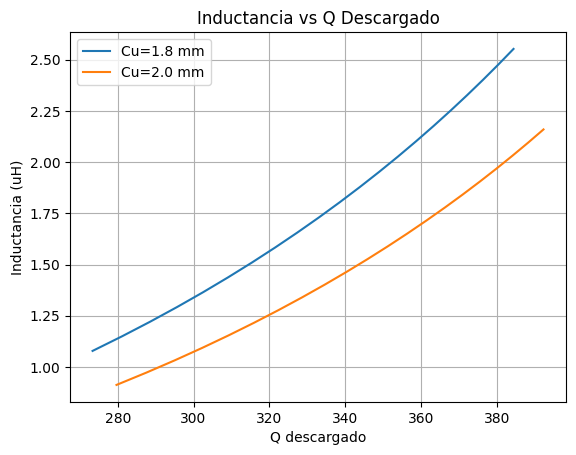

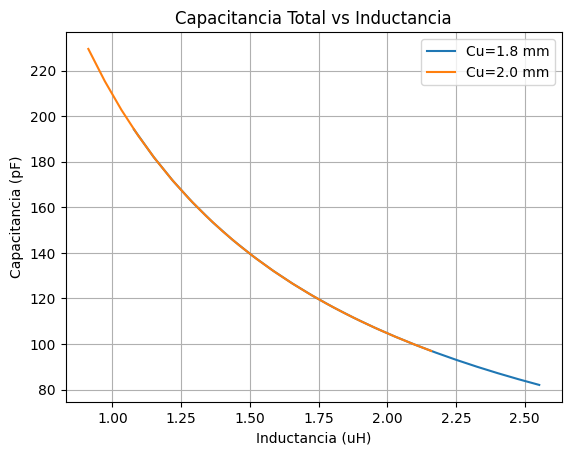

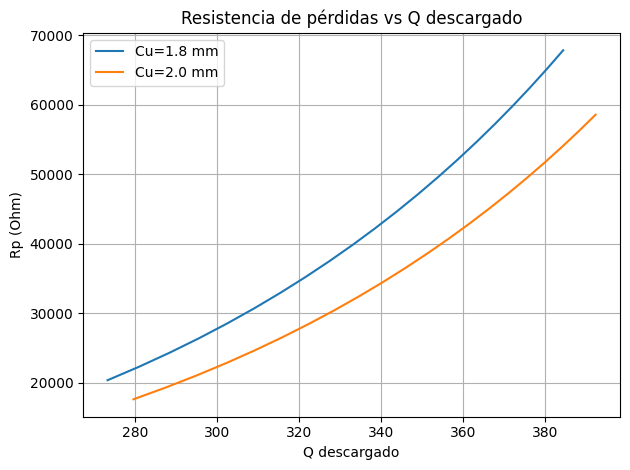

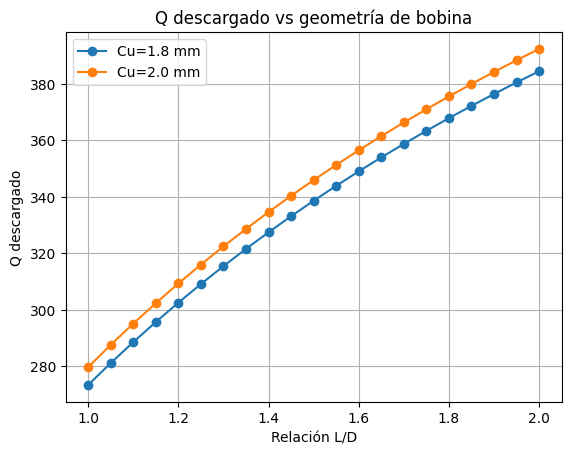

In [30]:
# ============
# 12. GRÁFICOS
# ============

# ------------------------------
# 12.1 Inductancia vs Q descargado
# ------------------------------

plt.figure()

for j in range(len(Diametros_cm)):
    plt.plot(Q_descargado[:,j], inductancia_uh[:,j],
             label=f'Cu={Diametros_cm[j]*10:.1f} mm')

plt.title('Inductancia vs Q Descargado')
plt.xlabel('Q descargado')
plt.ylabel('Inductancia (uH)')
plt.grid(True)
plt.legend()

plt.show()

# ------------------------------
# 12.2 Capacitancia vs inductancia
# ------------------------------

plt.figure()

for j in range(len(Diametros_cm)):
    plt.plot(inductancia_uh[:,j], C_total_pf[:,j],
             label=f'Cu={Diametros_cm[j]*10:.1f} mm')

plt.title('Capacitancia Total vs Inductancia')
plt.xlabel('Inductancia (uH)')
plt.ylabel('Capacitancia (pF)')
plt.grid(True)
plt.legend()

plt.show()

# ---------------------
# 12.3 Rp vs Q descargado
# ---------------------

plt.figure()

for j in range(len(Diametros_cm)):
    plt.plot(Q_descargado[:,j], RP[:,j],
             label=f'Cu={Diametros_cm[j]*10:.1f} mm')

plt.title('Resistencia de pérdidas vs Q descargado')
plt.xlabel('Q descargado')
plt.ylabel('Rp (Ohm)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# 12.4 Constructividad de bobina
# ----------------------------

plt.figure()

for j in range(len(Diametros_cm)):
    plt.plot(RelacionLD, Q_descargado[:,j], marker='o',
             label=f'Cu={Diametros_cm[j]*10:.1f} mm')

plt.xlabel("Relación L/D")
plt.ylabel("Q descargado")
plt.title("Q descargado vs geometría de bobina")
plt.grid()
plt.legend()

plt.show()

In [31]:
# =================
# 13. CÁLCULO DE RT
# =================

R_total = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
  for j in range(len(Diametros_cm)):
    
    XL = 2 * np.pi * f_res * (inductancia_uh[i, j] * 1e-6)
    R_total[i,j] = XL * QL_val

df_R_total = pd.DataFrame(R_total, index=filas, columns=columnas)

print("\nTABLA DE RESISTENCIA TOTAL (RT)")
print(df_R_total)


TABLA DE RESISTENCIA TOTAL (RT)
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00      745.225      630.457
L/D=1.05      794.224      671.909
L/D=1.10      843.547      713.636
L/D=1.15      893.164      755.612
L/D=1.20      943.048      797.814
L/D=1.25      993.177      840.222
L/D=1.30     1043.528      882.819
L/D=1.35     1094.084      925.589
L/D=1.40     1144.827      968.518
L/D=1.45     1195.743     1011.592
L/D=1.50     1246.819     1054.802
L/D=1.55     1298.042     1098.137
L/D=1.60     1349.403     1141.588
L/D=1.65     1400.890     1185.146
L/D=1.70     1452.496     1228.804
L/D=1.75     1504.211     1272.555
L/D=1.80     1556.030     1316.393
L/D=1.85     1607.945     1360.313
L/D=1.90     1659.949     1404.309
L/D=1.95     1712.038     1448.376
L/D=2.00     1764.206     1492.509


Utilizando el criterio de adaptación de la entrada del circuito se tiene que:

$$
R_g' = 2R_T
$$

$$
R_p//R_L' = 2R_T
$$

Mientras que las ecuaciones que relacionan los capacitores con las resistencias del circuito son:
$$
R_g' = \left(1+\frac{C_2}{C_1}\right)^2 R_g
$$

$$
R_L' = \left(1+\frac{C_4}{C_3}\right)^2 R_l
$$

Además de que la disposición de capacitores en el circuito nos permite escribir:

$$
\begin{cases}
\frac{C_1 C_2}{C_1 + C_2} = \frac{C}{2} \\
\frac{C_3 C_4}{C_3 + C_4} = \frac{C}{2}
\end{cases}
$$

Por lo que si sabemos que: $R_g = 50 \Omega$ y $R_L = 1000 \Omega$

Entonces:

In [32]:
import math
from scipy.optimize import fsolve
from scipy.optimize import least_squares


# 1. DEFINICIÓN DE VARIABLES
fila = 6
columna = 1
inductancia_uh_final = inductancia_uh[fila,columna]
Rt = R_total[fila,columna]
Ct = C_total[fila,columna]
Rp = RP[fila,columna]

# Valores de impedancia de fuente y carga
Rl = 1000
Rg = 50

# 2. DEFINICIÓN DEL SISTEMA DE ECUACIONES
def sistema_acople(c):
    # c = [C1, C2, C3, C4]
    C1, C2, C3, C4 = c

    # Ecuación 1: Transformación de Rg a 2*Rt
    # Rg' = Rg * (1 + C2/C1)^2
    eq1 = Rg * (1 + (C2/C1))**2 - (2 * Rt)

    # Ecuación 2: Transformación de Rl en paralelo con Rp a 2*Rt
    # Rl' = Rl * (1 + C4/C3)^2
    Rlp = Rl * (1 + (C4/C3))**2
    paralelo_carga = (Rp * Rlp) / (Rp + Rlp)
    eq2 = paralelo_carga - (2 * Rt)

    # Ecuación 3: Rama 1 (C1 serie C2) debe ser Ct/2
    eq3 = (C1 * C2) / (C1 + C2) - (Ct / 2)

    # Ecuación 4: Rama 2 (C3 serie C4) debe ser Ct/2
    eq4 = (C3 * C4) / (C3 + C4) - (Ct / 2)

    return [eq1, eq2, eq3, eq4]

# 3. RESOLUCIÓN
# Estimación inicial: se asume que los capacitores shunt son mayores que los serie
semilla = [Ct, Ct*10, Ct, Ct*2]
solucion = fsolve(sistema_acople, semilla)

C1_f, C2_f, C3_f, C4_f = solucion

# 4. IMPRESIÓN DE RESULTADOS
print(f"--- RESULTADOS DEL ACOPLE (Valores Ideales) ---")
print(f"Frecuencia de Resonancia: {f_res/1e6:.2f} MHz")
print(f"Inductancia final (If): {inductancia_uh_final:.4f} uH")
print(f"Resistencia total (Rt): {Rt:.4f} Ohms")
print(f"Resistencia de pérdida final (Rp): {Rp*1e-3:.4f} kOhms\n")

print(f"Capacidad Total (Ct): {Ct*1e12:.4f} pF")
print(f"C1: {C1_f*1e12:.4f} pF")
print(f"C2: {C2_f*1e12:.4f} pF")
print(f"C3: {C3_f*1e12:.4f} pF")
print(f"C4: {C4_f*1e12:.4f} pF\n")

# Verificación de resonancia
Ct_final = ((C1_f * C2_f) / (C1_f + C2_f)) + ((C3_f * C4_f) / (C3_f + C4_f))
f_res = 1 / (2 * np.pi * np.sqrt(inductancia_uh_final*1e-6* Ct_final))

print(f"--- VERIFICACIÓN ---")
print(f"Ct resultante: {Ct_final*1e12:.4f} pF (Error: {abs(Ct-Ct_final):.2e})")
print(f"Frecuencia resultante: {f_res/1e6:.4f} MHz")

--- RESULTADOS DEL ACOPLE (Valores Ideales) ---
Frecuencia de Resonancia: 11.00 MHz
Inductancia final (If): 1.2773 uH
Resistencia total (Rt): 882.8194 Ohms
Resistencia de pérdida final (Rp): 28.4624 kOhms

Capacidad Total (Ct): 163.8912 pF
C1: 98.5255 pF
C2: 486.9580 pF
C3: 302.2234 pF
C4: 112.4302 pF

--- VERIFICACIÓN ---
Ct resultante: 163.8912 pF (Error: 9.61e-23)
Frecuencia resultante: 11.0000 MHz


In [33]:
# 1. VALORES COMERCIALES DISPONIBLES (en pF)
comerciales = [10, 15, 22, 33, 47, 100, 120, 150, 180, 220, 330, 470, 560, 680, 820, 1000]

# 2. VALORES IDEALES A ALCANZAR (en pF)
ideales = {
    "C1": 98.5255,
    "C2": 486.958,
    "C3": 302.2234,
    "C4": 112.4302
}

def encontrar_mejor_combinacion(objetivo):
    mejor_valor = 0
    mejor_error = float('inf')
    mejor_descripcion = ""

    # Opción A: Un solo capacitor
    for c in comerciales:
        error = abs(c - objetivo)
        if error < mejor_error:
            mejor_error = error
            mejor_valor = c
            mejor_descripcion = f"{c} pF (Simple)"

    # Opción B: Dos en Paralelo (C = Ca + Cb)
    for i in range(len(comerciales)):
        for j in range(i, len(comerciales)):
            suma = comerciales[i] + comerciales[j]
            error = abs(suma - objetivo)
            if error < mejor_error:
                mejor_error = error
                mejor_valor = suma
                mejor_descripcion = f"{comerciales[i]} pF || {comerciales[j]} pF"

    # Opción C: Dos en Serie (C = (Ca * Cb) / (Ca + Cb))
    for i in range(len(comerciales)):
        for j in range(i, len(comerciales)):
            serie = (comerciales[i] * comerciales[j]) / (comerciales[i] + comerciales[j])
            error = abs(serie - objetivo)
            if error < mejor_error:
                mejor_error = error
                mejor_valor = serie
                mejor_descripcion = f"{comerciales[i]} pF serie {comerciales[j]} pF"

    return mejor_valor, mejor_descripcion

# 3. EJECUCIÓN Y RESULTADOS
print(f"{'Cap.':<5} | {'Ideal (pF)':<12} | {'Comercial (pF)':<15} | {'Configuración'}")
print("-" * 65)

capacitores_finales = {}
for nombre, valor_ideal in ideales.items():
    valor_com, desc = encontrar_mejor_combinacion(valor_ideal)
    capacitores_finales[nombre] = valor_com
    print(f"{nombre:<5} | {valor_ideal:<12.4f} | {valor_com:<15.4f} | {desc}")

# 4. VERIFICACIÓN DE IMPACTO EN CAPACIDAD TOTAL
CT_ideal = ((ideales["C1"]*ideales["C2"])/(ideales["C1"]+ideales["C2"])) + ((ideales["C3"]*ideales["C4"])/(ideales["C3"]+ideales["C4"]))
CT_comercial = ((capacitores_finales["C1"]*capacitores_finales["C2"])/(capacitores_finales["C1"]+capacitores_finales["C2"])) + ((capacitores_finales["C3"]*capacitores_finales["C4"])/(capacitores_finales["C3"]+capacitores_finales["C4"]))

print("\n--- ANÁLISIS DE DESVIACIÓN ---")
print(f"Capacidad Total Ideal: {CT_ideal:.4f} pF")
print(f"Capacidad Total con Comerciales: {CT_comercial:.4f} pF")
print(f"Error en CT: {abs(CT_ideal - CT_comercial):.4f} pF ({abs(1 - CT_comercial/CT_ideal)*100:.2f}%)")

Cap.  | Ideal (pF)   | Comercial (pF)  | Configuración
-----------------------------------------------------------------
C1    | 98.5255      | 98.8235         | 120 pF serie 560 pF
C2    | 486.9580     | 485.0000        | 15 pF || 470 pF
C3    | 302.2234     | 300.0000        | 120 pF || 180 pF
C4    | 112.4302     | 113.7097        | 150 pF serie 470 pF

--- ANÁLISIS DE DESVIACIÓN ---
Capacidad Total Ideal: 163.8912 pF
Capacidad Total con Comerciales: 164.5519 pF
Error en CT: 0.6607 pF (0.40%)


In [34]:
# ===============================
# 15. RECÁLCULO DE LA INDUCTANCIA
# ===============================

L = 1/((2*np.pi*f_res)**2 * CT_comercial/1e12)

L_uH = L*1e6

print("\nInductancia necesaria para resonar:")
print(L_uH,"uH")


Inductancia necesaria para resonar:
1.2721903645605075 uH


In [35]:
# ================================
# 16. CÁLCULO DE RT Y RP COMERCIAL
# ================================

# -------------------------
# 16.1 Resistencia Total RT
# -------------------------

XL = 2 * np.pi * f_res * (L_uH * 1e-6)

R_total = XL * QL_val

print("\nRESISTENCIA TOTAL AJUSTADA A VALORES COMERCIALES: ", R_total)

# ------------------------------
# 16.2 Resistencia de Pérdida RP
# ------------------------------

RP = np.zeros((len(RelacionLD), len(Diametros_cm)))

for i in range(len(RelacionLD)):
    for j in range(len(Diametros_cm)):

        XL = 2 * np.pi * f_res * (L_uH*1e-6)

        RP[i, j] = Q_descargado[i, j] * XL

df_RP = pd.DataFrame(RP, index=filas, columns=columnas)

print("\nTABLA DE RESISTENCIA DE PÉRDIDAS AJUSTADA A VALORES COMERCIALES (Ohm)")
print(df_RP)
print()



RESISTENCIA TOTAL AJUSTADA A VALORES COMERCIALES:  879.2748587198803

TABLA DE RESISTENCIA DE PÉRDIDAS AJUSTADA A VALORES COMERCIALES (Ohm)
          d_cu=0.18cm  d_cu=0.20cm
L/D=1.00    24036.006    24591.345
L/D=1.05    24716.065    25282.734
L/D=1.10    25368.575    25945.891
L/D=1.15    25995.179    26582.511
L/D=1.20    26597.387    27194.154
L/D=1.25    27176.599    27782.263
L/D=1.30    27734.105    28348.170
L/D=1.35    28271.105    28893.109
L/D=1.40    28788.709    29418.225
L/D=1.45    29287.949    29924.579
L/D=1.50    29769.785    30413.159
L/D=1.55    30235.113    30884.886
L/D=1.60    30684.765    31340.616
L/D=1.65    31119.522    31781.150
L/D=1.70    31540.111    32207.234
L/D=1.75    31947.213    32619.570
L/D=1.80    32341.467    33018.810
L/D=1.85    32723.472    33405.571
L/D=1.90    33093.790    33780.427
L/D=1.95    33452.949    34143.920
L/D=2.00    33801.447    34496.559



Como no se puede medir la frecuencia central sin introducir error con los instrumentos, utilizando las siguientes ecuaciones, se determina el valor de la frecuencia central con mediciones indirectas:

$$
f_0' = \frac{1}{2\pi \sqrt{L.C_m}}
$$

$$
f_0'' = \frac{1}{2\pi \sqrt{L.(C_x + C_m)}}
$$

$C_m$ corresponde a la capacitancia de medición, la cual contiene la componente que agrega el osciloscopio y el generador. Mientras que $C_x$ corresponde a un valor de un capacitor a elección que corra la frecuencia central, tal que al agregar una ecuación extra se pueda despejar el valor de inductancia primero, y luego la frecuencia central.

In [36]:
# ------------------------------------------
# CÁLCULO INDIRECTO DE LA FRECUENCIA CENTRAL
# ------------------------------------------

import numpy as np

# Datos
fop = 10.75e6
fopp = 8.5e6
Cx = 120e-12
Ct = 164.5519e-12

# Calculo Cm a partir del despeje de ecuaciones
Cm = Cx / ((fop/fopp)**2 - 1)

# Calculo L
L = 1 / ((2*np.pi*fop)**2 * Cm)

# Frecuencia final
fo = 1/(2*np.pi*np.sqrt(Ct*L))

print(f"L = {L*1e6:.5} uH")
print(f"Cm = {Cm*1e12:.6} pF")
print(f"fo = {fo/1e6:.5} MHz")

L = 1.095 uH
Cm = 200.173 pF
fo = 11.857 MHz
